# Image Anomaly Detection met AutoEncoder

**Dataset:** normale afbeeldingen zijn zwart-witte gezichtsfoto's.  
**Anomaly-afbeeldingen:** objecten zoals auto, kat, gebouw, telefoon, stoel, bloem, fiets, eten, vliegtuig en tafel.

Het idee van deze opdracht is: de autoencoder leert normale gezichtsfoto's reconstrueren. Afwijkende afbeeldingen worden minder goed gereconstrueerd, waardoor de **MSE-score** hoger wordt.

Labels in deze notebook:

- `0` = normal
- `1` = anomaly


## 1. Imports en instellingen

In [1]:
# Als je een package mist, kan je deze regel eenmalig gebruiken:
# %pip install tensorflow pillow scikit-learn pandas matplotlib

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import Model, layers, losses
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


## 2. Paden naar de folders

Zet je afbeeldingen in deze twee folders:

- `normal_images`: gezichtsfoto's
- `anomaly_images`: afwijkende afbeeldingen


In [2]:
normal_folder = "normal_images"
anomaly_folder = "anomaly_images"

print("Normal folder bestaat:", os.path.exists(normal_folder))
print("Anomaly folder bestaat:", os.path.exists(anomaly_folder))


Normal folder bestaat: True
Anomaly folder bestaat: True


## 3. Afbeeldingen inladen en preprocessen

Elke afbeelding wordt:

1. geopend met PIL;
2. omgezet naar zwart-wit (`grayscale`);
3. geresized naar `28 x 28`;
4. genormaliseerd naar waarden tussen `0` en `1`.


In [3]:
def load_images_from_folder(folder_path, image_size=(28, 28)):
    images = []
    filenames = []

    for filename in sorted(os.listdir(folder_path)):
        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            image_path = os.path.join(folder_path, filename)

            image = Image.open(image_path).convert("L")
            image = image.resize(image_size, Image.LANCZOS)
            image_array = np.array(image, dtype="float32") / 255.0

            images.append(image_array)
            filenames.append(filename)

    return np.array(images, dtype="float32"), filenames

normal_images, normal_filenames = load_images_from_folder(normal_folder)
anomaly_images, anomaly_filenames = load_images_from_folder(anomaly_folder)

print("Aantal normal images:", len(normal_images))
print("Aantal anomaly images:", len(anomaly_images))
print("Shape normal images:", normal_images.shape)
print("Shape anomaly images:", anomaly_images.shape)


Aantal normal images: 499
Aantal anomaly images: 11
Shape normal images: (499, 28, 28)
Shape anomaly images: (11, 28, 28)


## 4. Voorbeelden bekijken

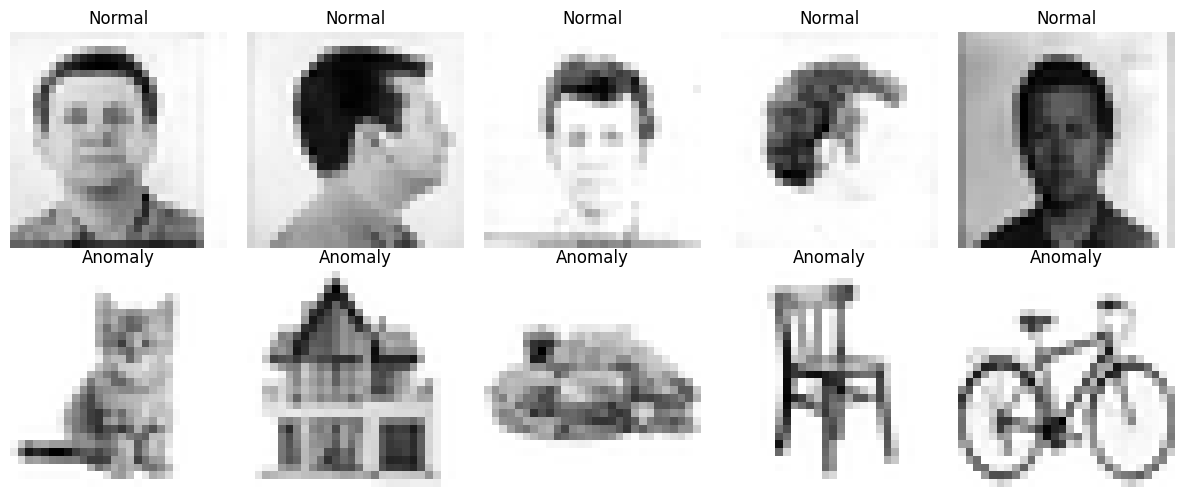

In [4]:
def show_examples(normal_images, anomaly_images, amount=5):
    amount_normal = min(amount, len(normal_images))
    amount_anomaly = min(amount, len(anomaly_images))

    plt.figure(figsize=(12, 5))

    for i in range(amount_normal):
        plt.subplot(2, amount, i + 1)
        plt.imshow(normal_images[i], cmap="gray")
        plt.title("Normal")
        plt.axis("off")

    for i in range(amount_anomaly):
        plt.subplot(2, amount, i + 1 + amount)
        plt.imshow(anomaly_images[i], cmap="gray")
        plt.title("Anomaly")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_examples(normal_images, anomaly_images, amount=5)


## 5. Train/test split

De autoencoder wordt alleen getraind op **normal images**.  
Daarna wordt getest op normal images én anomaly images.


In [5]:
x_train, x_test_normal, train_names, test_normal_names = train_test_split(
    normal_images,
    normal_filenames,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

x_test_all = np.concatenate([x_test_normal, anomaly_images], axis=0)

y_true_normal = np.zeros(len(x_test_normal), dtype=int)
y_true_anomaly = np.ones(len(anomaly_images), dtype=int)
y_true = np.concatenate([y_true_normal, y_true_anomaly], axis=0)

test_filenames = list(test_normal_names) + list(anomaly_filenames)

print("Train set:", x_train.shape)
print("Test normal set:", x_test_normal.shape)
print("Test anomaly set:", anomaly_images.shape)
print("Test all:", x_test_all.shape)
print("Labels:", y_true.shape)


Train set: (399, 28, 28)
Test normal set: (100, 28, 28)
Test anomaly set: (11, 28, 28)
Test all: (111, 28, 28)
Labels: (111,)


# Deel 1: Voorbeeld AutoEncoder model van de docent

Dit model lijkt op het voorbeeld uit de les:

- `Flatten`: maakt van `28 x 28` één vector van `784` waarden.
- `Dense(latent_dim, relu)`: comprimeert de afbeelding.
- `Dense(784, sigmoid)`: maakt de reconstructie.
- `Reshape`: maakt weer een `28 x 28` afbeelding.


In [6]:
def train_autoencoder(x_train, x_test, latent_dim=164, num_epochs=150):
    class Autoencoder(Model):
        def __init__(self, latent_dim):
            super(Autoencoder, self).__init__()
            self.latent_dim = latent_dim

            self.encoder = tf.keras.Sequential([
                layers.Flatten(),
                layers.Dense(latent_dim, activation="relu")
            ])

            self.decoder = tf.keras.Sequential([
                layers.Dense(28 * 28, activation="sigmoid"),
                layers.Reshape((28, 28))
            ])

        def call(self, x):
            encoded = self.encoder(x)
            decoded = self.decoder(encoded)
            return decoded

    autoencoder = Autoencoder(latent_dim)

    autoencoder.compile(
        optimizer="adam",
        loss=losses.MeanSquaredError()
    )

    history = autoencoder.fit(
        x_train,
        x_train,
        epochs=num_epochs,
        shuffle=True,
        validation_data=(x_test, x_test)
    )

    return autoencoder, history


## 6. Voorbeeld model trainen

In [7]:
voorbeeld_model, voorbeeld_history = train_autoencoder(
    x_train=x_train,
    x_test=x_test_normal,
    latent_dim=164,
    num_epochs=50
)


Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0809 - val_loss: 0.0525
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0453 - val_loss: 0.0447
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0414 - val_loss: 0.0417
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0385 - val_loss: 0.0387
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0354 - val_loss: 0.0355
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0325 - val_loss: 0.0328
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0303 - val_loss: 0.0310
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0288 - val_loss: 0.0297
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0277 - val_loss: 0.0288
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0268 - val_loss: 0.0279
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0260 - val_loss: 0.0271
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0252 - val_lo

## 7. Loss plot voorbeeld model

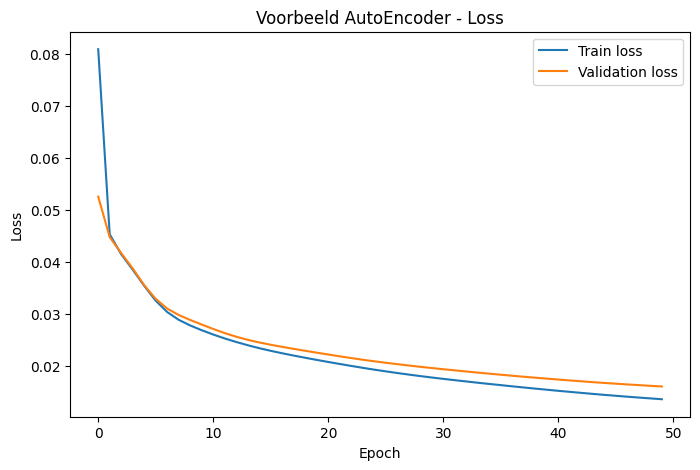

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(voorbeeld_history.history["loss"], label="Train loss")
plt.plot(voorbeeld_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Voorbeeld AutoEncoder - Loss")
plt.legend()
plt.show()


## 8. Reconstructies bekijken

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


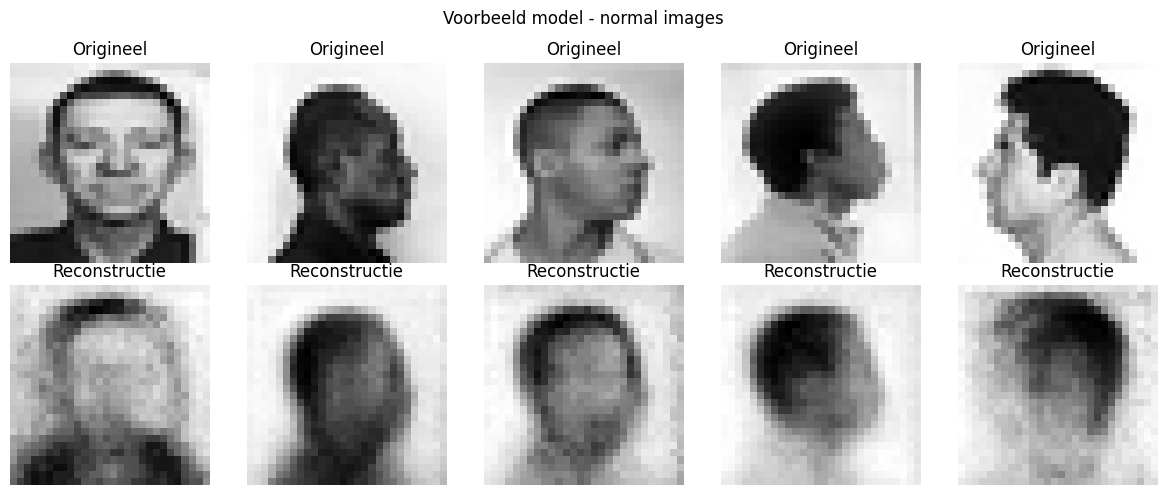

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


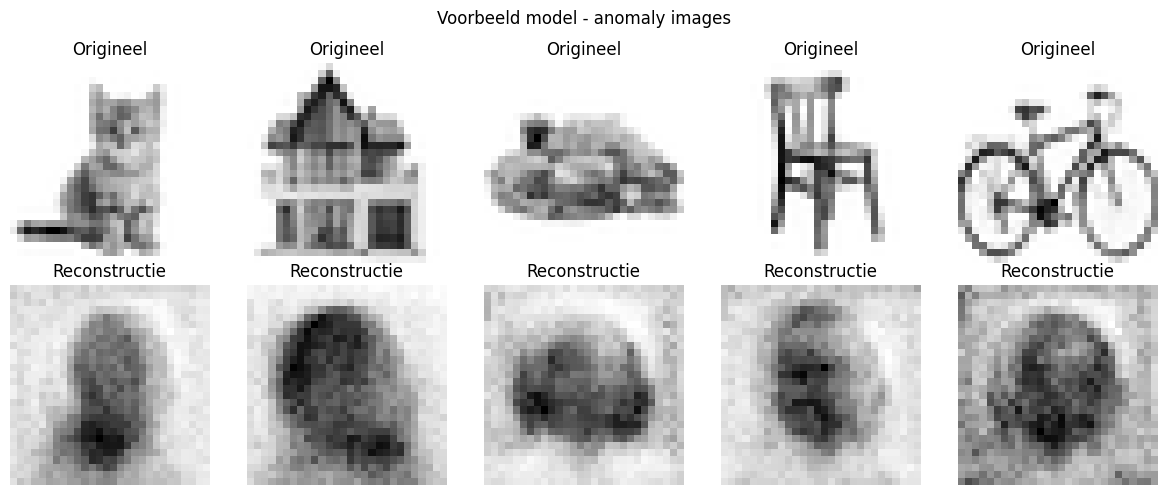

In [9]:
def show_reconstructions(model, images, title, amount=5):
    amount = min(amount, len(images))
    predictions = model.predict(images[:amount])

    plt.figure(figsize=(12, 5))

    for i in range(amount):
        plt.subplot(2, amount, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.title("Origineel")
        plt.axis("off")

        plt.subplot(2, amount, i + 1 + amount)
        plt.imshow(predictions[i], cmap="gray")
        plt.title("Reconstructie")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_reconstructions(voorbeeld_model, x_test_normal, "Voorbeeld model - normal images")
show_reconstructions(voorbeeld_model, anomaly_images, "Voorbeeld model - anomaly images")


## 9. MSE-score berekenen

MSE betekent **Mean Squared Error**.  
Een hoge MSE betekent dat het verschil tussen origineel en reconstructie groot is.


In [10]:
def calculate_mse(model, images):
    reconstructed_images = model.predict(images)
    mse_scores = np.mean(np.square(images - reconstructed_images), axis=(1, 2))
    return mse_scores

voorbeeld_mse_scores = calculate_mse(voorbeeld_model, x_test_all)

voorbeeld_result_df = pd.DataFrame({
    "filename": test_filenames,
    "true_label": y_true,
    "mse_score": voorbeeld_mse_scores
})

voorbeeld_result_df


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,filename,true_label,mse_score
0,00089_2_F.png,0,0.022745
1,00014_2_R.png,0,0.007307
2,00045_1_R.png,0,0.009445
3,00034_3_R.png,0,0.005482
4,00046_1_L.png,0,0.027896
...,...,...,...
106,download (6).jpeg,1,0.019283
107,download (7).jpeg,1,0.036747
108,download (8).jpeg,1,0.034066
109,download (9).jpeg,1,0.046409


## 10. MSE-scores visualiseren

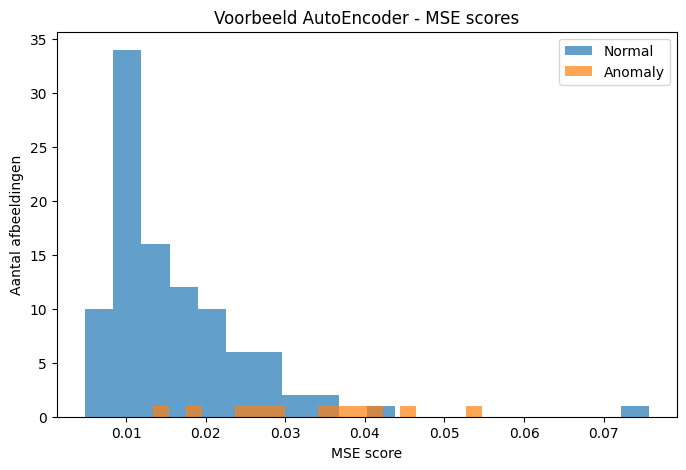

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(voorbeeld_mse_scores[y_true == 0], bins=20, alpha=0.7, label="Normal")
plt.hist(voorbeeld_mse_scores[y_true == 1], bins=20, alpha=0.7, label="Anomaly")
plt.xlabel("MSE score")
plt.ylabel("Aantal afbeeldingen")
plt.title("Voorbeeld AutoEncoder - MSE scores")
plt.legend()
plt.show()


## 11. Threshold kiezen

Hier gebruiken we de 95e percentiel van de normale MSE-scores als threshold.  
Dat betekent: als een afbeelding een hogere MSE heeft dan deze grens, dan noemen we die afbeelding een anomaly.


In [12]:
voorbeeld_normal_mse = voorbeeld_mse_scores[y_true == 0]
voorbeeld_threshold = np.percentile(voorbeeld_normal_mse, 95)

print("Voorbeeld threshold:", voorbeeld_threshold)

voorbeeld_y_pred = (voorbeeld_mse_scores > voorbeeld_threshold).astype(int)
voorbeeld_result_df["predicted_label"] = voorbeeld_y_pred
voorbeeld_result_df


Voorbeeld threshold: 0.03040895


,filename,true_label,mse_score,predicted_label
0,00089_2_F.png,0,0.022745,0
1,00014_2_R.png,0,0.007307,0
2,00045_1_R.png,0,0.009445,0
3,00034_3_R.png,0,0.005482,0
4,00046_1_L.png,0,0.027896,0
...,...,...,...,...
106,download (6).jpeg,1,0.019283,0
107,download (7).jpeg,1,0.036747,1
108,download (8).jpeg,1,0.034066,1
109,download (9).jpeg,1,0.046409,1


## 12. Confusion matrix voorbeeld model

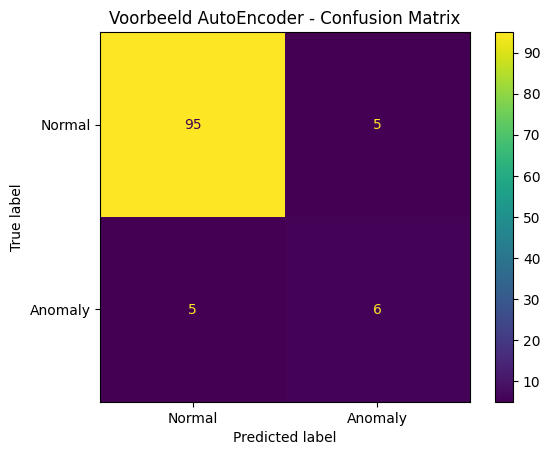

              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95       100
     Anomaly       0.55      0.55      0.55        11

    accuracy                           0.91       111
   macro avg       0.75      0.75      0.75       111
weighted avg       0.91      0.91      0.91       111



In [13]:
cm = confusion_matrix(y_true, voorbeeld_y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

display.plot()
plt.title("Voorbeeld AutoEncoder - Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    voorbeeld_y_pred,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))


# Deel 2: Eigen AutoEncoder model

Dit is mijn eigen model. Het is dieper dan het voorbeeldmodel.  
De encoder maakt de afbeelding stap voor stap kleiner. De decoder probeert daarna de afbeelding opnieuw te maken.


In [14]:
def train_eigen_autoencoder(x_train, x_test, latent_dim=64, num_epochs=150):
    class EigenAutoencoder(Model):
        def __init__(self, latent_dim):
            super(EigenAutoencoder, self).__init__()
            self.latent_dim = latent_dim

            self.encoder = tf.keras.Sequential([
                layers.Flatten(),
                layers.Dense(256, activation="relu"),
                layers.Dense(128, activation="relu"),
                layers.Dense(latent_dim, activation="relu")
            ])

            self.decoder = tf.keras.Sequential([
                layers.Dense(128, activation="relu"),
                layers.Dense(256, activation="relu"),
                layers.Dense(28 * 28, activation="sigmoid"),
                layers.Reshape((28, 28))
            ])

        def call(self, x):
            encoded = self.encoder(x)
            decoded = self.decoder(encoded)
            return decoded

    autoencoder = EigenAutoencoder(latent_dim)

    autoencoder.compile(
        optimizer="adam",
        loss=losses.MeanSquaredError()
    )

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    history = autoencoder.fit(
        x_train,
        x_train,
        epochs=num_epochs,
        shuffle=True,
        validation_data=(x_test, x_test),
        callbacks=[early_stopping]
    )

    return autoencoder, history


## 13. Eigen model trainen

In [15]:
eigen_model, eigen_history = train_eigen_autoencoder(
    x_train=x_train,
    x_test=x_test_normal,
    latent_dim=64,
    num_epochs=150
)


Epoch 1/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0733 - val_loss: 0.0475
Epoch 2/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0446 - val_loss: 0.0450
Epoch 3/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0428 - val_loss: 0.0443
Epoch 4/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0418 - val_loss: 0.0430
Epoch 5/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0401 - val_loss: 0.0401
Epoch 6/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0366 - val_loss: 0.0365
Epoch 7/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0338 - val_loss: 0.0332
Epoch 8/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0306 - val_loss: 0.0303
Epoch 9/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0289 - val_loss: 0.0309
Epoch 10/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0280 - val_loss: 0.0298
Epoch 11/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0270 - val_loss: 0.0287
Epoch 12/150
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

## 14. Loss plot eigen model

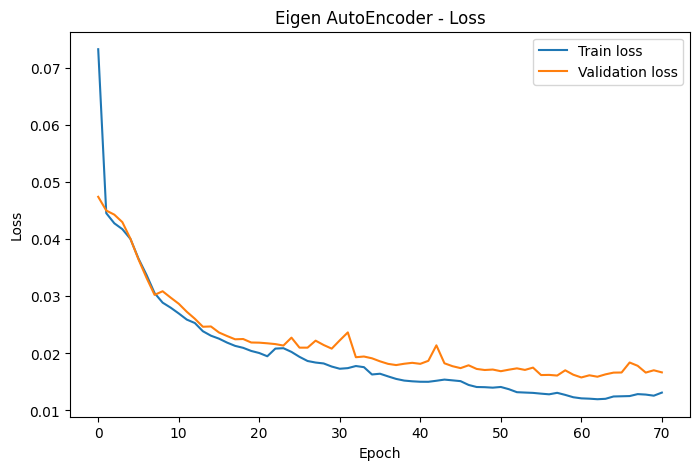

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(eigen_history.history["loss"], label="Train loss")
plt.plot(eigen_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Eigen AutoEncoder - Loss")
plt.legend()
plt.show()


## 15. Reconstructies eigen model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


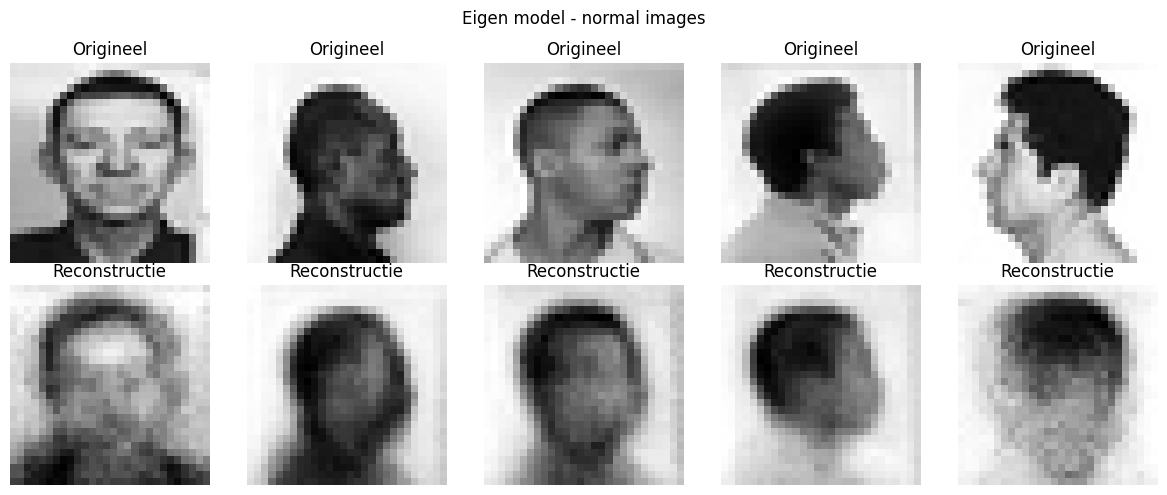

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


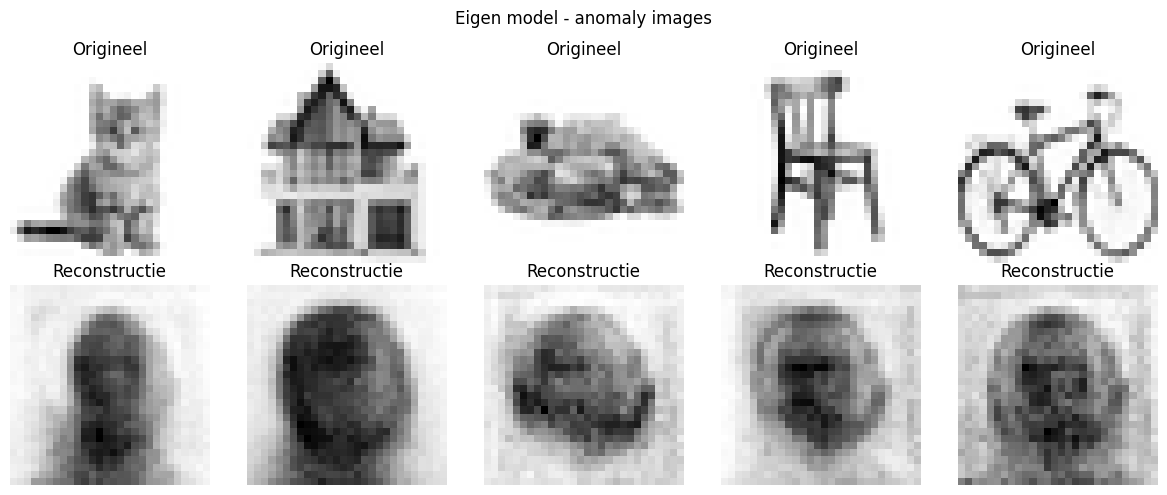

In [17]:
show_reconstructions(eigen_model, x_test_normal, "Eigen model - normal images")
show_reconstructions(eigen_model, anomaly_images, "Eigen model - anomaly images")


## 16. MSE-score eigen model

In [18]:
eigen_mse_scores = calculate_mse(eigen_model, x_test_all)

eigen_result_df = pd.DataFrame({
    "filename": test_filenames,
    "true_label": y_true,
    "mse_score": eigen_mse_scores
})

eigen_result_df


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


,filename,true_label,mse_score
0,00089_2_F.png,0,0.028386
1,00014_2_R.png,0,0.009289
2,00045_1_R.png,0,0.009130
3,00034_3_R.png,0,0.006411
4,00046_1_L.png,0,0.027170
...,...,...,...
106,download (6).jpeg,1,0.016631
107,download (7).jpeg,1,0.036644
108,download (8).jpeg,1,0.024053
109,download (9).jpeg,1,0.043289


## 17. MSE-scores eigen model visualiseren

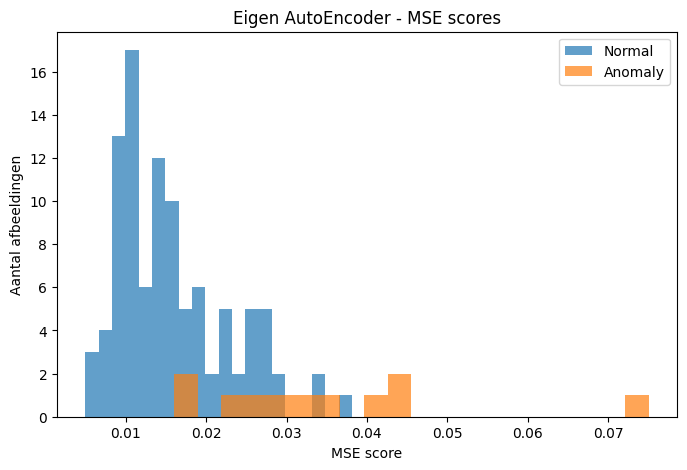

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(eigen_mse_scores[y_true == 0], bins=20, alpha=0.7, label="Normal")
plt.hist(eigen_mse_scores[y_true == 1], bins=20, alpha=0.7, label="Anomaly")
plt.xlabel("MSE score")
plt.ylabel("Aantal afbeeldingen")
plt.title("Eigen AutoEncoder - MSE scores")
plt.legend()
plt.show()


## 18. Threshold en anomaly labels eigen model

In [20]:
eigen_normal_mse = eigen_mse_scores[y_true == 0]
eigen_threshold = np.percentile(eigen_normal_mse, 95)

print("Eigen threshold:", eigen_threshold)

eigen_y_pred = (eigen_mse_scores > eigen_threshold).astype(int)
eigen_result_df["predicted_label"] = eigen_y_pred
eigen_result_df


Eigen threshold: 0.027550273


,filename,true_label,mse_score,predicted_label
0,00089_2_F.png,0,0.028386,1
1,00014_2_R.png,0,0.009289,0
2,00045_1_R.png,0,0.009130,0
3,00034_3_R.png,0,0.006411,0
4,00046_1_L.png,0,0.027170,0
...,...,...,...,...
106,download (6).jpeg,1,0.016631,0
107,download (7).jpeg,1,0.036644,1
108,download (8).jpeg,1,0.024053,0
109,download (9).jpeg,1,0.043289,1


## 19. Confusion matrix eigen model

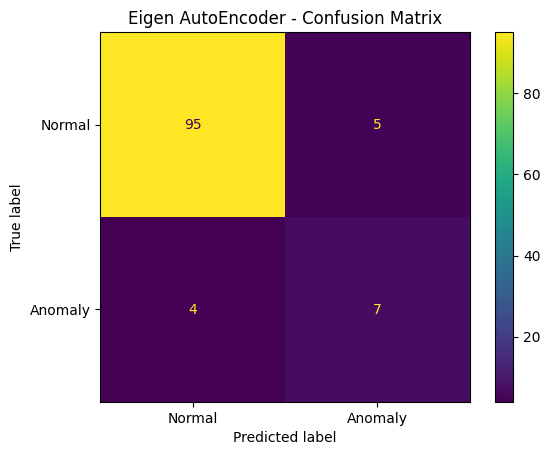

              precision    recall  f1-score   support

      Normal       0.96      0.95      0.95       100
     Anomaly       0.58      0.64      0.61        11

    accuracy                           0.92       111
   macro avg       0.77      0.79      0.78       111
weighted avg       0.92      0.92      0.92       111



In [21]:
cm = confusion_matrix(y_true, eigen_y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomaly"]
)

display.plot()
plt.title("Eigen AutoEncoder - Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    eigen_y_pred,
    target_names=["Normal", "Anomaly"],
    zero_division=0
))


## 20. Vergelijking tussen voorbeeld model en eigen model

In [22]:
vergelijking_df = pd.DataFrame({
    "model": ["Voorbeeld model", "Eigen model"],
    "threshold": [voorbeeld_threshold, eigen_threshold],
    "accuracy": [accuracy_score(y_true, voorbeeld_y_pred), accuracy_score(y_true, eigen_y_pred)],
    "precision": [precision_score(y_true, voorbeeld_y_pred, zero_division=0), precision_score(y_true, eigen_y_pred, zero_division=0)],
    "recall": [recall_score(y_true, voorbeeld_y_pred, zero_division=0), recall_score(y_true, eigen_y_pred, zero_division=0)],
    "f1": [f1_score(y_true, voorbeeld_y_pred, zero_division=0), f1_score(y_true, eigen_y_pred, zero_division=0)],
    "voorspelde_anomalies": [int(np.sum(voorbeeld_y_pred)), int(np.sum(eigen_y_pred))],
    "echte_anomalies": [int(np.sum(y_true)), int(np.sum(y_true))]
})

vergelijking_df


,model,threshold,accuracy,precision,recall,f1,voorspelde_anomalies,echte_anomalies
0,Voorbeeld model,0.030409,0.909910,0.545455,0.545455,0.545455,11,11
1,Eigen model,0.027550,0.918919,0.583333,0.636364,0.608696,12,11


# Portfolio vragen over eigen AutoEncoder model

## Hoeveel lagen heb je gebruikt?
Mijn eigen autoencoder gebruikt 8 belangrijke lagen: Flatten, Dense 256, Dense 128, Dense latent_dim, Dense 128, Dense 256, Dense output en Reshape.

## Welke lagen heb je gebruikt?
Ik heb vooral Dense-lagen gebruikt. De encoder maakt de afbeelding kleiner en haalt belangrijke kenmerken uit de afbeelding. De decoder probeert daarna de afbeelding opnieuw te reconstrueren.

Ik heb ook Flatten gebruikt om de afbeelding van 28x28 om te zetten naar één vector. Aan het einde gebruik ik Reshape om de vector weer terug te zetten naar een afbeelding van 28x28.

## Wat doen deze lagen?
Flatten zet de afbeelding om naar een lijst met getallen. Dense-lagen leren patronen in de afbeelding. De latent_dim-laag comprimeert de informatie. Reshape maakt van de output weer een afbeelding.

## Welke activation functions worden gebruikt en waarom?
Ik gebruik ReLU in de meeste Dense-lagen. ReLU werkt vaak goed in neurale netwerken en helpt het model patronen te leren. In de laatste laag gebruik ik sigmoid, omdat de pixels tussen 0 en 1 liggen.

## Hoe groot is je train/test set?
De train set bestaat uit 80% van de normale afbeeldingen. De test set bestaat uit 20% van de normale afbeeldingen plus de anomaly afbeeldingen.

## Wat doet je encoding dim?
De encoding dim bepaalt hoe klein de afbeelding wordt samengeperst. Een lagere latent_dim betekent meer compressie. Daardoor kan het model minder details onthouden. Dit kan helpen om anomalies beter te herkennen, omdat afwijkende afbeeldingen moeilijker goed gereconstrueerd worden.

## Welke loss functie heb je gebruikt in het optimaliseren en waarom?
Ik heb Mean Squared Error gebruikt. Deze loss functie past goed bij een autoencoder, omdat we het verschil tussen de originele afbeelding en de gereconstrueerde afbeelding willen meten. Een hoge MSE betekent dat het model de afbeelding slecht heeft gereconstrueerd. Daarom kan MSE ook gebruikt worden voor anomaly detection.


# Conclusie

In deze opdracht heb ik een autoencoder gebruikt om anomaly detection te doen op afbeeldingen. De normale dataset bestaat uit zwart-witte gezichtsfoto’s. De autoencoder wordt alleen getraind op normale afbeeldingen. Daarna test ik het model op normale afbeeldingen en anomaly afbeeldingen.

Voor elke afbeelding bereken ik de MSE-score tussen de originele afbeelding en de reconstructie. Als de MSE-score hoger is dan de threshold, wordt de afbeelding gelabeld als anomaly.

Het idee is dat normale gezichtsfoto’s goed gereconstrueerd kunnen worden, omdat het model daarop getraind is. Afwijkende afbeeldingen zoals een auto, kat, gebouw, vliegtuig of stoel worden minder goed gereconstrueerd. Daardoor krijgen deze afbeeldingen meestal een hogere MSE-score.
